# 1. ПОДГОТОВИТЕЛЬНАЯ РАБОТА 


## 1.1. Загрузить данные

In [1]:
# 1.1.1 Устанавливаю и импортирую библиотеки
!pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from scipy import stats

# Настраиваю pandas для удобного просмотра данных
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Библиотеки загружены:")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Seaborn version:", sns.__version__)

Библиотеки загружены:
Pandas version: 2.3.3
NumPy version: 2.4.1
Seaborn version: 0.13.2


In [2]:
# Смотрю, какие файлы есть в папке data
data_path = os.path.join('..', 'data')

print("Файлы в папке data:")
print("-" * 30)

# Проверяю, существует ли папка
if os.path.exists(data_path):
    # Получаю список всех файлов в папке
    files = os.listdir(data_path)
    
    # Прохожу по каждому файлу в цикле
    for file in files:
        # Составляю полный путь к файлу
        file_path = os.path.join(data_path, file)
        
        # Проверяю, что это файл, а не папка
        if os.path.isfile(file_path):
            # Получаю размер файла в байтах и перевожу в мегабайты
            size_bytes = os.path.getsize(file_path)
            size_mb = size_bytes / (1024 * 1024)
            
            # Вывожу информацию о файле
            print(f"{file}: {size_mb:.2f} МБ")
else:
    print(f"Папка {data_path} не найдена!")

Файлы в папке data:
------------------------------
ga_hits.csv: 4068.87 МБ
ga_hits.pkl: 4191.90 МБ
ga_sessions.csv: 370.09 МБ
ga_sessions.pkl: 377.11 МБ


In [ ]:
# .csv файлы — это обычные текстовые файлы с данными. Они занимают много места и читаются медленно.
# .pkl файлы — это файлы в специальном формате Python. Они читаются быстрее, но, требуют много оперативной памяти.

In [4]:
# Загружаю данные о сессиях из ga_sessions.csv
sessions_full = pd.read_csv(
    os.path.join(data_path, 'ga_sessions.csv'),
    encoding='utf-8'
)

print("Размер загруженных данных:", sessions_full.shape)
print("\nПервые 5 строк:")
sessions_full.head()

C:\Users\User\AppData\Local\Temp\ipykernel_1780\579353988.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  sessions_full = pd.read_csv(


Размер загруженных данных: (1860042, 18)

Первые 5 строк:


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [ ]:
# pandas "сообщает", что в колонке client_id числа и текст перемешаны.

In [5]:
# Загружаю первые 200,000 строк из ga_hits.csv
# Полный файл весит 4 ГБ и не поместится в память
# 200 000 строк должно хватить для анализа
hits_sample = pd.read_csv(
    os.path.join(data_path, 'ga_hits.csv'),
    nrows=200000,
    encoding='utf-8'
)

print("Размер загруженных данных:", hits_sample.shape)
print("\nПервые 5 строк:")
hits_sample.head()

Размер загруженных данных: (200000, 11)

Первые 5 строк:


,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


In [7]:
# 200 000 строк загрузились без ошибок

In [9]:
####

## 1.2. Оценка полноты и чистоты данных

In [6]:
# Проверяю пропуски в данных сессий
missing_sessions = sessions_full.isnull().sum()
missing_percent_sessions = (missing_sessions / len(sessions_full)) * 100

# Собираю в таблицу
missing_df_sessions = pd.DataFrame({
    'колонка': missing_sessions.index,
    'пропусков': missing_sessions.values,
    'процент': missing_percent_sessions.values
})

# Показываю только те колонки, где есть пропуски
print("Пропуски в данных сессий (только колонки с пропусками):")
missing_df_sessions[missing_df_sessions.пропусков > 0].sort_values('процент', ascending=False)

Пропуски в данных сессий (только колонки с пропусками):


,колонка,пропусков,процент
13,device_model,1843704,99.121633
9,utm_keyword,1082061,58.174009
11,device_os,1070138,57.533002
12,device_brand,367178,19.740307
8,utm_adcontent,335615,18.043410
7,utm_campaign,219603,11.806346
5,utm_source,97,0.005215


In [ ]:
# Анализ пропусков:
# device_model - 99.1% — практически нет данных. Эту колонку удалю.
# utm_keyword - 58.2%  — ключевые слова. Пропуски могут означать, что кампания не использовала ключевые слова.
# device_os - 57.5% — операционная система. Много пропусков, но колонка важная.
# device_brand - 19.7% — марка устройства. Важная информация.
# utm_adcontent - 18.0% — содержание объявления.
# utm_campaign - 11.8% — название кампании.
# utm_source - 0.005% — всего 97 пропусков из 1.8 млн, можно не обращать внимание.

In [8]:
####

## 1.3. Обработка пропусков и дубликатов

In [10]:
# Создаю копию, чтобы не менять исходные данные
sessions_clean = sessions_full.copy()

# device_model (99% пропусков) — удаляю, так как данных практически нет
sessions_clean = sessions_clean.drop('device_model', axis=1)
print("Удалила колонку device_model")

# device_os и device_brand — заполняю пропуски значением 'unknown'
sessions_clean['device_os'] = sessions_clean['device_os'].fillna('unknown')
sessions_clean['device_brand'] = sessions_clean['device_brand'].fillna('unknown')
print("Заполнила пропуски в device_os и device_brand значением 'unknown'")

# utm_keyword, utm_adcontent, utm_campaign — оставляю как есть
# Пропуски там могут означать, что в рекламной кампании не использовались эти параметры
print("Пропуски в utm-метках оставляю - это норма для рекламных данных")

# Проверяю, что осталось
missing_after = sessions_clean.isnull().sum()
print("\nПропуски после обработки (только колонки с пропусками):")
print(missing_after[missing_after > 0])

Удалила колонку device_model
Заполнила пропуски в device_os и device_brand значением 'unknown'
Пропуски в utm-метках оставляю - это норма для рекламных данных

Пропуски после обработки (только колонки с пропусками):
utm_source            97
utm_campaign      219603
utm_adcontent     335615
utm_keyword      1082061
dtype: int64


In [ ]:
# остались только utm-колонки. Теперь проверю дубликаты.

In [11]:
# Проверяю дубликаты по session_id (должен быть уникальным)
duplicates = sessions_clean.duplicated(subset=['session_id']).sum()
print(f"Найдено дубликатов session_id: {duplicates}")

# Если есть дубликаты, показываю их
if duplicates > 0:
    print("\nПримеры дубликатов:")
    sessions_clean[sessions_clean.duplicated(subset=['session_id'], keep=False)].sort_values('session_id').head()

Найдено дубликатов session_id: 0


In [ ]:
# Дубликатов нет — данные чистые. 
# Теперь приведу типы данных в порядок.

In [12]:
#####

## 1.5. Привожу типы данных к правильному формату

In [51]:
# Приведение типов данных
print("Типы данных до преобразования:")
print(sessions_clean.dtypes)
print("\n" + "-"*30 + "\n")

# Преобразую visit_date в формат даты
sessions_clean['visit_date'] = pd.to_datetime(sessions_clean['visit_date'])

# Явно привожу client_id к строковому типу
sessions_clean['client_id'] = sessions_clean['client_id'].astype(str)

print("Типы данных после преобразования:")
print(sessions_clean.dtypes)
print("\n" + "-"*30 + "\n")

# Проверяю, что client_id действительно стал строкой
print("Примеры client_id после преобразования:")
print(sessions_clean['client_id'].head())
print(f"\nТип первой записи: {type(sessions_clean['client_id'].iloc[0])}")

Типы данных до преобразования:
session_id                          object
client_id                           object
visit_date                  datetime64[ns]
visit_time                          object
visit_number                         int64
utm_source                          object
utm_medium                          object
utm_campaign                        object
utm_adcontent                       object
utm_keyword                         object
device_category                     object
device_os                           object
device_brand                        object
device_screen_resolution            object
device_browser                      object
geo_country                         object
geo_city                            object
dtype: object

------------------------------

Типы данных после преобразования:
session_id                          object
client_id                           object
visit_date                  datetime64[ns]
visit_time                  

In [52]:
# данные стали чище

In [53]:
#####

# 2. РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)

## 2.1. Анализ сессий (ga_sessions)

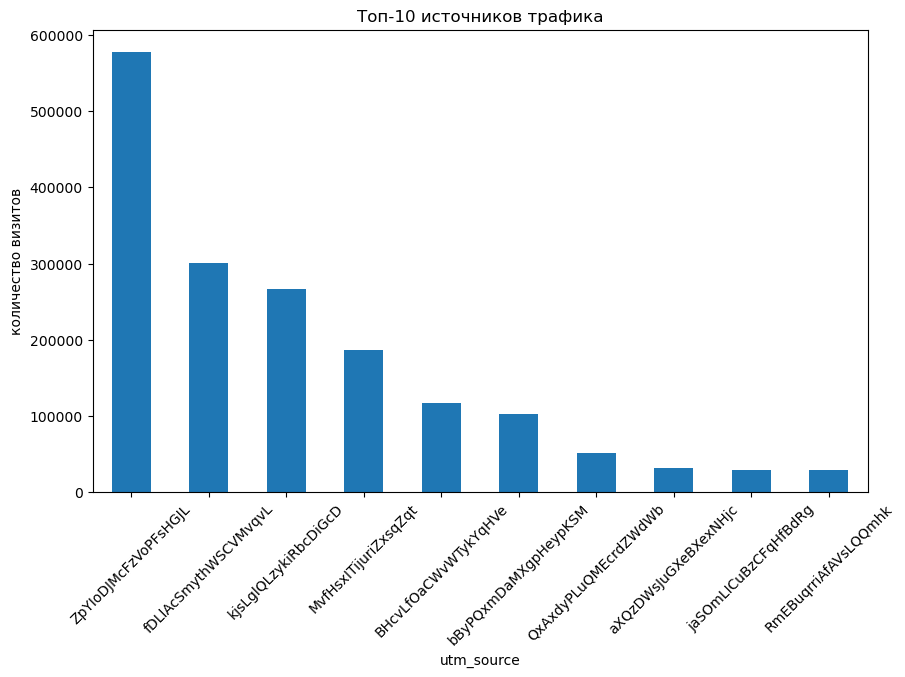

Топ-10 источников трафика:
utm_source
ZpYIoDJMcFzVoPFsHGJL    578290
fDLlAcSmythWSCVMvqvL    300575
kjsLglQLzykiRbcDiGcD    266354
MvfHsxITijuriZxsqZqt    186199
BHcvLfOaCWvWTykYqHVe    116320
bByPQxmDaMXgpHeypKSM    102287
QxAxdyPLuQMEcrdZWdWb     51415
aXQzDWsJuGXeBXexNHjc     31152
jaSOmLICuBzCFqHfBdRg     29241
RmEBuqrriAfAVsLQQmhk     28055
Name: count, dtype: int64


In [17]:
# Распределение по источникам трафика (utm_source)
source_dist = sessions_clean['utm_source'].value_counts().head(10)

# Строю график
plt.figure(figsize=(10, 6))
source_dist.plot(kind='bar')
plt.title('Топ-10 источников трафика')
plt.xlabel('utm_source')
plt.ylabel('количество визитов')
plt.xticks(rotation=45)
plt.show()

print("Топ-10 источников трафика:")
print(source_dist)

In [ ]:
# 578 290 визитов с первого источника!

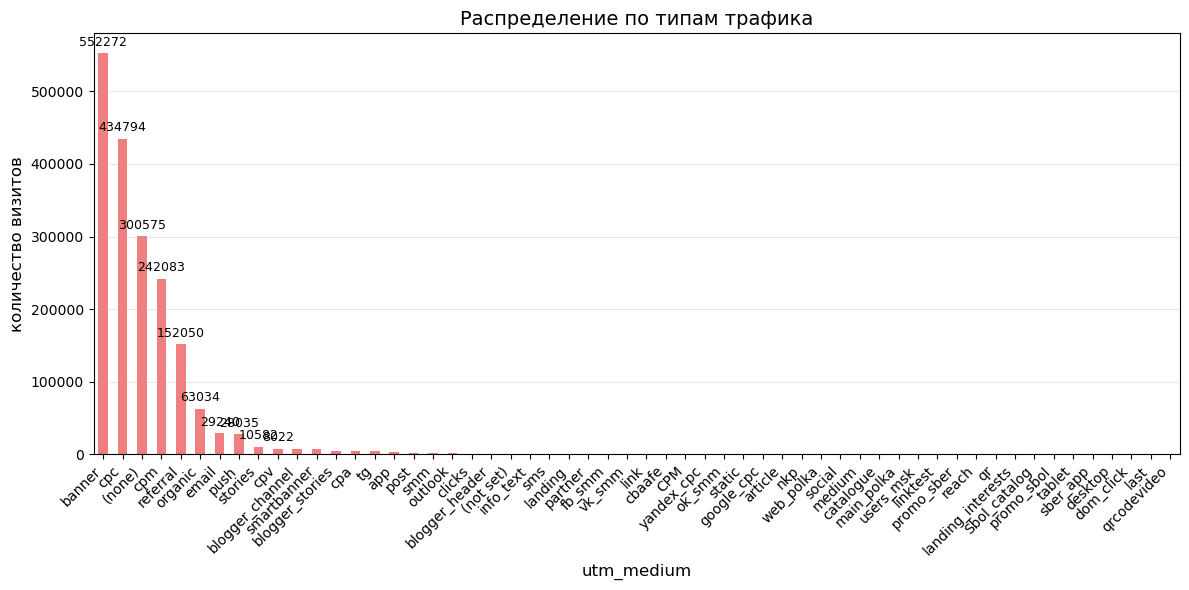

Распределение по типам трафика (топ-20):
utm_medium
banner             552272
cpc                434794
(none)             300575
cpm                242083
referral           152050
organic             63034
email               29240
push                28035
stories             10582
cpv                  8022
blogger_channel      8015
smartbanner          6794
blogger_stories      4312
cpa                  4279
tg                   4011
app                  2836
post                 2326
smm                  1985
outlook              1332
clicks                934
Name: count, dtype: int64


In [19]:
# Распределение по типам трафика (utm_medium)
medium_dist = sessions_clean['utm_medium'].value_counts()

# Строю график
plt.figure(figsize=(12, 6))
medium_dist.plot(kind='bar', color='lightcoral')
plt.title('Распределение по типам трафика', fontsize=14)
plt.xlabel('utm_medium', fontsize=12)
plt.ylabel('количество визитов', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Добавляю подписи значений (для топ-10, чтобы не загромождать)
for i, v in enumerate(medium_dist.values[:10]):
    plt.text(i, v + 10000, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Распределение по типам трафика (топ-20):")
print(medium_dist.head(20))

In [ ]:
# banner — лидер по объёму / 552 272 визита
# cpc (платные клики) / на втором месте
# (none) — прямой трафик / 300 575 визитов
# organic — органический поиск / 63 034 визита

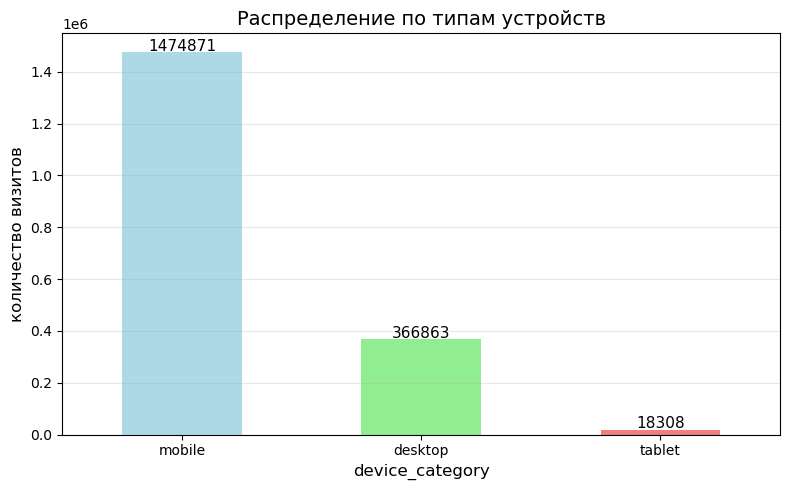

Распределение по типам устройств:
device_category
mobile     1474871
desktop     366863
tablet       18308
Name: count, dtype: int64


In [20]:
# Распределение по типам устройств
device_dist = sessions_clean['device_category'].value_counts()

# Строю график
plt.figure(figsize=(8, 5))
colors = ['lightblue', 'lightgreen', 'lightcoral']
device_dist.plot(kind='bar', color=colors)
plt.title('Распределение по типам устройств', fontsize=14)
plt.xlabel('device_category', fontsize=12)
plt.ylabel('количество визитов', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Добавляю подписи значений
for i, v in enumerate(device_dist.values):
    plt.text(i, v + 5000, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print("Распределение по типам устройств:")
print(device_dist)

In [ ]:
# Мобильные устройства - на первом месте
# Десктоп — 366 863
# Планшеты — всего 18 308

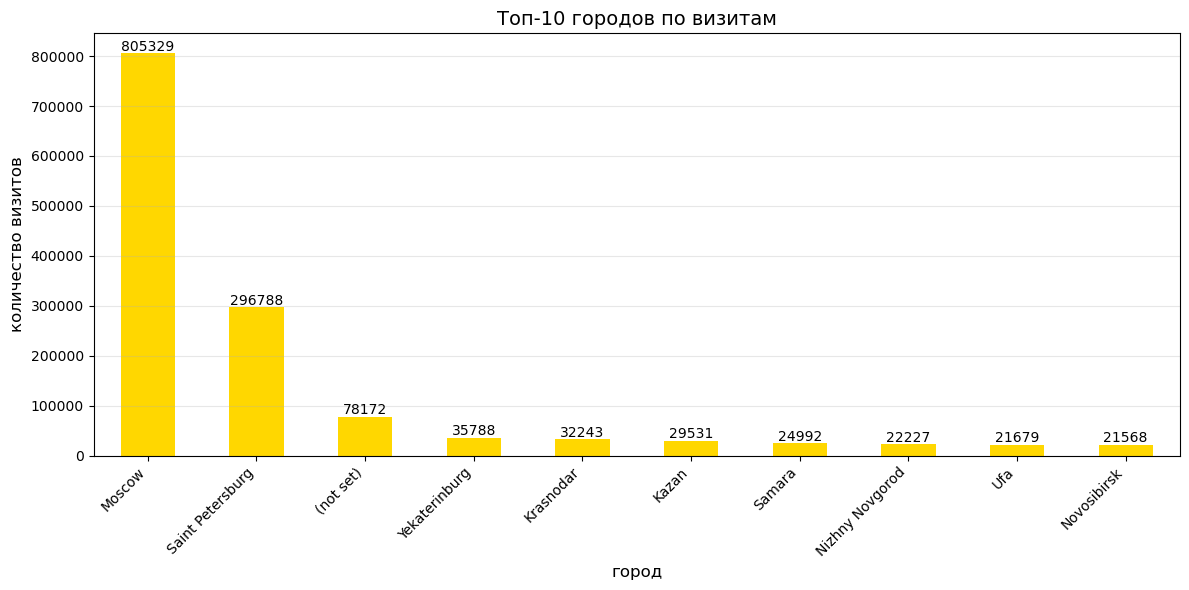

Топ-10 городов по визитам:
geo_city
Moscow              805329
Saint Petersburg    296788
(not set)            78172
Yekaterinburg        35788
Krasnodar            32243
Kazan                29531
Samara               24992
Nizhny Novgorod      22227
Ufa                  21679
Novosibirsk          21568
Name: count, dtype: int64


In [21]:
# Топ-10 городов по визитам
city_dist = sessions_clean['geo_city'].value_counts().head(10)

# Строю график
plt.figure(figsize=(12, 6))
city_dist.plot(kind='bar', color='gold')
plt.title('Топ-10 городов по визитам', fontsize=14)
plt.xlabel('город', fontsize=12)
plt.ylabel('количество визитов', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Добавляю подписи значений
for i, v in enumerate(city_dist.values):
    plt.text(i, v + 5000, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Топ-10 городов по визитам:")
print(city_dist)

In [ ]:
# Москва и Питер - лидируют с огромным отрывом. 
# not set — 78 172 визита с неизвестным городом.

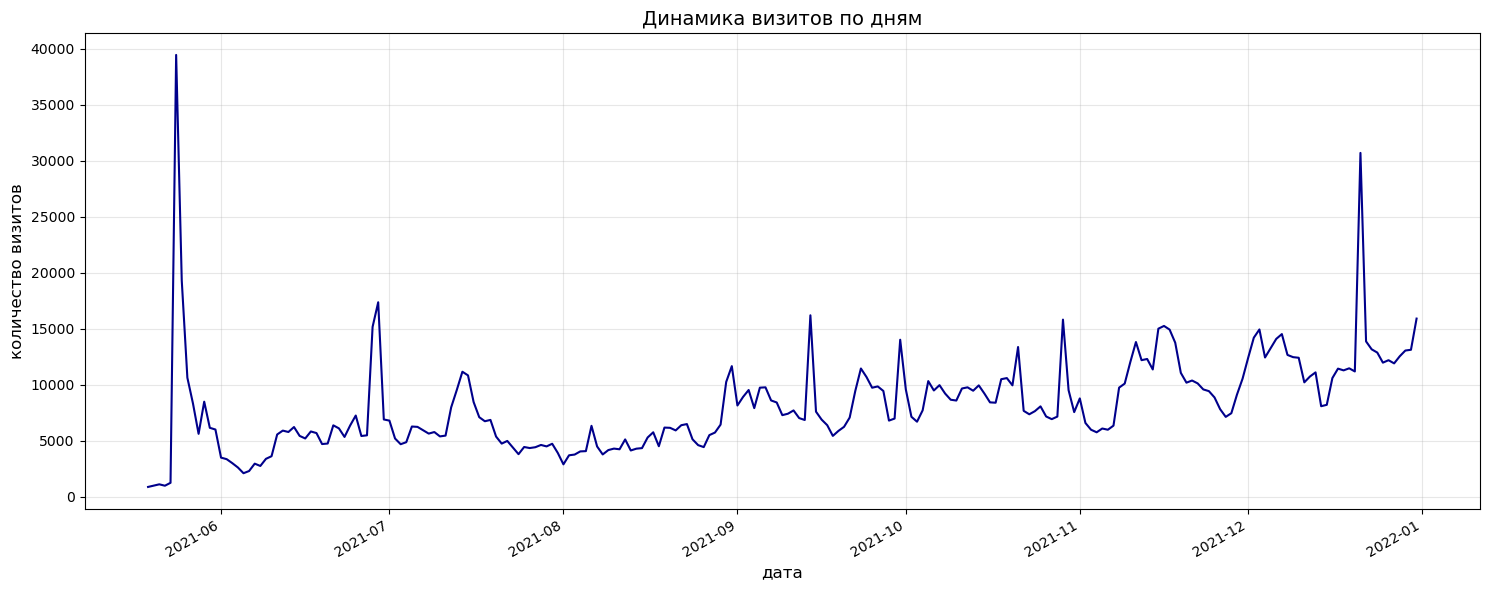

Статистика по дням:
Минимум: 877
Максимум: 39453
Среднее: 8230.3
Медиана: 7326.0


In [23]:
# Динамика визитов по дням
# Группирую по датам и считаю количество визитов
daily_visits = sessions_clean.groupby('visit_date').size()

# Строю график
plt.figure(figsize=(15, 6))
daily_visits.plot(kind='line', color='darkblue')
plt.title('Динамика визитов по дням', fontsize=14)
plt.xlabel('дата', fontsize=12)
plt.ylabel('количество визитов', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Статистика по дням:")
print(f"Минимум: {daily_visits.min()}")
print(f"Максимум: {daily_visits.max()}")
print(f"Среднее: {daily_visits.mean():.1f}")
print(f"Медиана: {daily_visits.median():.1f}")

In [50]:
# Огромный разброс — от 877 до 39 453 визитов в день. 
# Это говорит о неравномерной активности: возможно, были рекламные кампании, которые давали резкие всплески трафика.

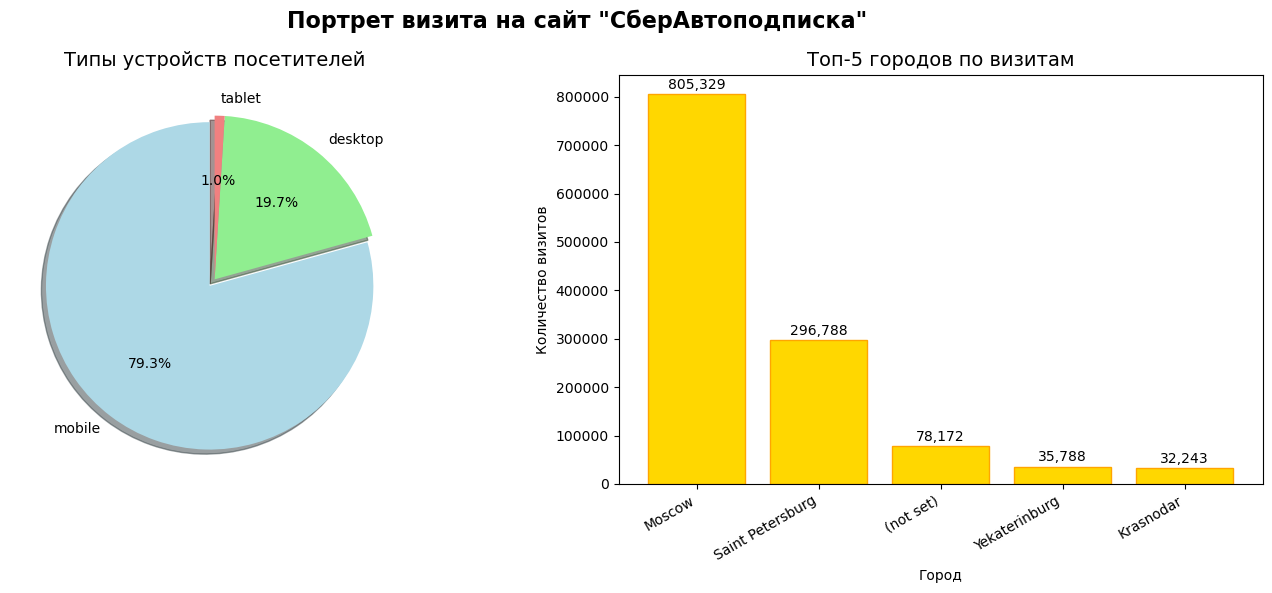

Ключевые выводы о визитах:
Мобильные устройства: 1,474,871 визитов (79.3%)
Москва: 805,329 визитов
Санкт-Петербург: 296,788 визитов
В среднем 8230 визитов в день


In [25]:
# Визуализация: портрет визита на сайт
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Первый график: распределение по типам устройств (круговая диаграмма)
device_counts = sessions_clean['device_category'].value_counts()
colors = ['lightblue', 'lightgreen', 'lightcoral']
explode = (0.05, 0, 0)  # немного выделяю первую категорию

axes[0].pie(device_counts.values, 
            labels=device_counts.index, 
            colors=colors,
            explode=explode,
            autopct='%1.1f%%',
            startangle=90,
            shadow=True)
axes[0].set_title('Типы устройств посетителей', fontsize=14)

# Второй график: топ-5 городов (столбчатая диаграмма)
top_cities = sessions_clean['geo_city'].value_counts().head(5)
bars = axes[1].bar(range(len(top_cities)), top_cities.values, color='gold', edgecolor='orange')
axes[1].set_title('Топ-5 городов по визитам', fontsize=14)
axes[1].set_xlabel('Город')
axes[1].set_ylabel('Количество визитов')
axes[1].set_xticks(range(len(top_cities)))
axes[1].set_xticklabels(top_cities.index, rotation=30, ha='right')

# Добавлю подписи значений на столбцы
for bar, value in zip(bars, top_cities.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 5000,
                 f'{value:,}', ha='center', va='bottom', fontsize=10)

# Общий заголовок
fig.suptitle('Портрет визита на сайт "СберАвтоподписка"', 
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# Добавляю текстовые выводы
print("Ключевые выводы о визитах:")
print(f"Мобильные устройства: {device_counts['mobile']:,} визитов ({device_counts['mobile']/len(sessions_clean)*100:.1f}%)")
print(f"Москва: {top_cities['Moscow']:,} визитов")
print(f"Санкт-Петербург: {top_cities['Saint Petersburg']:,} визитов")
print(f"В среднем {daily_visits.mean():.0f} визитов в день")

## 2.2. Анализ событий (ga_hits) и создание целевой переменной

In [26]:
# Знакомлюсь с данными о событиях
print("Размер данных:", hits_sample.shape)
print("\nКолонки:", hits_sample.columns.tolist())
print("\nТипы данных:")
print(hits_sample.dtypes)
print("\nПервые 5 строк:")
hits_sample.head()

Размер данных: (200000, 11)

Колонки: ['session_id', 'hit_date', 'hit_time', 'hit_number', 'hit_type', 'hit_referer', 'hit_page_path', 'event_category', 'event_action', 'event_label', 'event_value']

Типы данных:
session_id         object
hit_date           object
hit_time          float64
hit_number          int64
hit_type           object
hit_referer        object
hit_page_path      object
event_category     object
event_action       object
event_label        object
event_value       float64
dtype: object

Первые 5 строк:


,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


In [53]:
# 200 000 строк, 11 колонок 
# Типы данных в основном object 
# hit_time и event_value — числа с плавающей точкой

### 2.2.1 — Создаём целевую переменную

In [27]:
# Создаю целевую переменную
# Список целевых действий из глоссария
target_actions = [
    'sub_car_claim_click',
    'sub_car_claim_submit_click',
    'sub_open_dialog_click',
    'sub_custom_question_submit_click',
    'sub_call_number_click',
    'sub_callback_submit_click',
    'sub_submit_success',
    'sub_car_request_submit_click'
]

# Создаю целевую переменную: 1 если действие в списке, иначе 0
hits_sample['target'] = hits_sample['event_action'].isin(target_actions).astype(int)

# Проверяю, сколько целевых действий в выборке
print("Распределение целевой переменной:")
print(hits_sample['target'].value_counts())
print(f"\nДоля целевых действий: {hits_sample['target'].mean()*100:.4f}%")

Распределение целевой переменной:
target
0    199024
1       976
Name: count, dtype: int64

Доля целевых действий: 0.4880%


In [55]:
# Код работает правильно
# Целевая переменная создаётся корректно
# В выборке из 200 000 строк нашлось 976 целевых действий. 
# Это 0.488% — примерно полпроцента. 
# Нормальная история — целевые действия всегда редкие.

In [29]:
# Топ-10 самых частых действий
top_actions = hits_sample['event_action'].value_counts().head(10)
print("Топ-10 самых частых действий:")
print(top_actions)

Топ-10 самых частых действий:
event_action
view_card                  37117
view_new_card              36127
sub_landing                23364
go_to_car_card             11118
sub_view_cars_click        10222
showed_number_ads           9759
search_form_region          8295
search_form_search_btn      7098
sap_search_form_cost_to     6886
pagination_click            6434
Name: count, dtype: int64


In [ ]:
# Пользователи в основном просматривают карточки view_card, view_new_card
# и останавливаются на лендинги sub_landing 
# Целевых действий пока не видно в топе, но это нормально — они редкие

In [30]:
####

### 2.2.2. Анализ категорий событий (самые частые категории)

In [31]:
# Топ-10 самых частых категорий событий
top_categories = hits_sample['event_category'].value_counts().head(10)
print("Топ-10 самых частых категорий:")
print(top_categories)

Топ-10 самых частых категорий:
event_category
card_web            76667
search_form         45958
sub_page_view       23858
sub_button_click    12708
listing_ads         12053
cars                 9208
sap_search_form      6886
sap_search__form     4009
auth                 2449
quiz                 1988
Name: count, dtype: int64


In [ ]:
# вижу реальную картину по категориям:
# card_web — 76 667 событий (просмотр карточек авто)
# search_form — 45 958 событий (работа с поиском)
# sub_page_view — 23 858 событий (просмотр страниц подписки)
# sub_button_click — 12 708 событий (клики по кнопкам подписки)

In [32]:
# Целевые действия
target_events = hits_sample[hits_sample['target'] == 1]['event_action'].value_counts()
print("\nЦелевые действия:")
print(target_events)


Целевые действия:
event_action
sub_car_claim_click                 342
sub_submit_success                  213
sub_open_dialog_click               203
sub_car_claim_submit_click          136
sub_car_request_submit_click         30
sub_callback_submit_click            25
sub_call_number_click                23
sub_custom_question_submit_click      4
Name: count, dtype: int64


In [ ]:
# реальная картина целевых действий:
# sub_car_claim_click — 342 / клик по заявке на авто
# sub_submit_success — 213 / успешная отправка формы
# sub_open_dialog_click — 203 / открытие диалога
# sub_car_claim_submit_click — 136 / отправка заявки
# sub_car_request_submit_click — 30 / отправка запроса
# sub_callback_submit_click — 25 / отправка запроса на звонок
# sub_call_number_click — 23 / клик по номеру телефона
# sub_custom_question_submit_click — 4 / отправка своего вопроса

# Вывод:
# целевые действия найдены, но они привязаны только к hits_sample. 
# Чтобы считать конверсии по источникам трафика, устройствам и городам, 
# объединю эти данные с таблицей сессий sessions_clean.

In [33]:
####

### 2.3. Объединение таблицы сессий и событий

In [34]:
# Объединяю таблицы для расчёта конверсий
# Беру только нужные колонки из sessions_clean, чтобы не тащить лишнее
merged_data = pd.merge(
    hits_sample,
    sessions_clean[['session_id', 'utm_source', 'utm_medium', 'device_category', 'geo_city']],
    on='session_id',
    how='left'
)

print("Размер объединённых данных:", merged_data.shape)
print("\nПервые 5 строк:")
merged_data.head()

Размер объединённых данных: (200000, 16)

Первые 5 строк:


,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value,target,utm_source,utm_medium,device_category,geo_city
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN,0,kjsLglQLzykiRbcDiGcD,cpc,mobile,Saint Petersburg
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN,0,ZpYIoDJMcFzVoPFsHGJL,banner,mobile,Chelyabinsk
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN,0,BHcvLfOaCWvWTykYqHVe,cpc,desktop,Moscow
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN,0,BHcvLfOaCWvWTykYqHVe,cpc,mobile,Podolsk
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN,0,fDLlAcSmythWSCVMvqvL,(none),desktop,Tallinn


In [ ]:
# Объединение прошло успешно. 
# Теперь у меня в merged_data есть всё необходимое:
# target — целевое действие или нет
# utm_source, utm_medium — откуда пришёл пользователь
# device_category — тип устройства
# geo_city — город

### 2.3.1. Общая конверсия

In [35]:
# Общая конверсия по выборке
total_events = len(merged_data)
total_targets = merged_data['target'].sum()
conversion_rate = (total_targets / total_events * 100).round(2)

print("Общая статистика:")
print(f"Всего событий: {total_events}")
print(f"Целевых событий: {total_targets}")
print(f"Общая конверсия: {conversion_rate}%")

Общая статистика:
Всего событий: 200000
Целевых событий: 976
Общая конверсия: 0.49%


In [ ]:
# Общая статистика по выборке из 200 000 событий:
# найдено 976 целевых действий (заявки, звонки, открытие диалогов)
# общая конверсия составила 0.49%
# это означает, что примерно 1 из 200 действий пользователя приводит к целевому событию
# такой показатель конверсии характерен для сайтов с длинным циклом принятия решения, как в моём случае.

In [36]:
####

### 2.3.2. Конверсия по источникам трафика (utm_source)

In [37]:
# Конверсия по источникам трафика
conv_by_source = merged_data.groupby('utm_source').agg(
    total_events=('target', 'count'),
    target_events=('target', 'sum')
).reset_index()

# Добавляю столбец с конверсией в процентах
conv_by_source['conversion_rate'] = (conv_by_source['target_events'] / conv_by_source['total_events'] * 100).round(2)

# Сортирую по убыванию конверсии и показываю топ-20
print("Конверсия по источникам трафика (топ-20):")
conv_by_source[conv_by_source['total_events'] > 10].sort_values('conversion_rate', ascending=False).head(20)

Конверсия по источникам трафика (топ-20):


,utm_source,total_events,target_events,conversion_rate
12,GmILPdZyuAVJCPsUBHeN,38,1,2.63
35,QxAxdyPLuQMEcrdZWdWb,5292,69,1.30
18,ISrKoXQCxqqYvAZICvjs,318,4,1.26
74,gVRrcxiDQubJiljoTbGm,167,2,1.20
90,oZCzWSykfixnjMPDNjSU,310,3,0.97
58,bByPQxmDaMXgpHeypKSM,7324,45,0.61
63,dyicZQGoeASogoSafjEh,669,4,0.60
83,kjsLglQLzykiRbcDiGcD,20121,119,0.59
81,jaSOmLICuBzCFqHfBdRg,361,2,0.55
1,BHcvLfOaCWvWTykYqHVe,13826,75,0.54


In [ ]:
# Анализ конверсии по источникам трафика:
# лидер по конверсии — GmILPdZyuAVJCPsUBHeN (2.63%), но объём очень маленький (38 событий)
# QxAxdyPLuQMEcrdZWdWb — 1.30%, 5292 события, 69 целевых (хороший источник) !!!
# gVRrcxiDQubJiljoTbGm и ISrKoXQCxqqYvAZICvjs — из списка соцсетей, конверсия выше среднего
# ZpYIoDJMcFzVoPFsHGJL — самый популярный источник (100 529 событий), 
# но конверсия 0.45% — чуть ниже общей (0.49%)
# kjsLglQLzykiRbcDiGcD — 0.59%, 20 121 событие, 119 целевых (хороший объём и конверсия)
# BHcvLfOaCWvWTykYqHVe — 0.54%, 13 826 событий, 75 целевых (тоже достойный результат)

In [38]:
###

### 2.3.3. Конверсия по типам трафика (utm_medium)

In [39]:
# Конверсия по типам трафика
conv_by_medium = merged_data.groupby('utm_medium').agg(
    total_events=('target', 'count'),
    target_events=('target', 'sum')
).reset_index()

conv_by_medium['conversion_rate'] = (conv_by_medium['target_events'] / conv_by_medium['total_events'] * 100).round(2)

# Сортирую и показываю
print("Конверсия по типам трафика:")
conv_by_medium[conv_by_medium['total_events'] > 10].sort_values('conversion_rate', ascending=False)

Конверсия по типам трафика:


,utm_medium,total_events,target_events,conversion_rate
4,app,48,1,2.08
9,clicks,56,1,1.79
28,smm,327,4,1.22
1,(not set),88,1,1.14
27,smartbanner,2246,23,1.02
10,cpa,970,8,0.82
11,cpc,37121,252,0.68
14,email,361,2,0.55
26,referral,11686,57,0.49
7,blogger_channel,1533,7,0.46


In [ ]:
# Анализ конверсии по типам трафика:
# app — самая высокая конверсия (2.08%), но всего 48 событий (скорее всего, внутренние переходы)
# clicks — 1.79%, тоже небольшой объём (56 событий)
# smm (соцсети) — 1.22%, 327 событий, 4 целевых — перспективное направление
# not set — 1.14%, возможно, прямой трафик или технические визиты
# smartbanner — 1.02%, 2246 событий, 23 целевых — мобильный баннер даёт хороший результат
# cpc (платные клики) — 0.68%, 37 121 событие, 252 целевых — основной драйвер целевых действий
# referral — 0.49%, 11 686 событий — на уровне общей конверсии
# banner — 0.44%, 95 871 событие — большой объём, но конверсия ниже среднего
# organic — 0.15%, 10 694 события — самая низкая конверсия среди популярных типов трафика

In [40]:
####

### 2.3.4. Конверсия по типам устройств

In [41]:
# Конверсия по типам устройств
conv_by_device = merged_data.groupby('device_category').agg(
    total_events=('target', 'count'),
    target_events=('target', 'sum')
).reset_index()

conv_by_device['conversion_rate'] = (conv_by_device['target_events'] / conv_by_device['total_events'] * 100).round(2)

print("Конверсия по типам устройств:")
print(conv_by_device)

Конверсия по типам устройств:
  device_category  total_events  target_events  conversion_rate
0         desktop         39564            163             0.41
1          mobile        157618            765             0.49
2          tablet          1681              2             0.12


In [42]:
# Анализ конверсии по типам устройств:
# мобильные устройства лидируют по конверсии (0.49%) и объёму трафика (78.8% всех событий)
# десктоп показывает чуть более низкую конверсию (0.41%), но тоже значимый объём (19.8%)
# планшеты дают самую низкую конверсию (0.12%) и минимальный трафик (менее 1%)
# мобильная версия сайта работает эффективнее десктопной, что важно учитывать

In [43]:
###

### 2.3.5 — Конверсия по городам

In [44]:
# Конверсия по городам
conv_by_city = merged_data.groupby('geo_city').agg(
    total_events=('target', 'count'),
    target_events=('target', 'sum')
).reset_index()

conv_by_city['conversion_rate'] = (conv_by_city['target_events'] / conv_by_city['total_events'] * 100).round(2)

# Фильтр: города с минимум 100 событиями, сортировка по убыванию конверсии
conv_by_city_filtered = conv_by_city[conv_by_city['total_events'] > 100].sort_values('conversion_rate', ascending=False)

print("Топ-20 городов по конверсии (событий > 100):")
print(conv_by_city_filtered.head(20))

Топ-20 городов по конверсии (событий > 100):
         geo_city  total_events  target_events  conversion_rate
162    Domodedovo           582             19             3.26
183        Elista           155              4             2.58
326      Korolyov           488             10             2.05
95        Bishkek           180              3             1.67
611     Sertolovo           128              2             1.56
743   Vladikavkaz           198              3             1.52
637         Sochi           830             11             1.33
41    Arkhangelsk           228              3             1.32
457       Nalchik           229              3             1.31
404   Makhachkala           560              7             1.25
480       Norilsk           186              2             1.08
332     Kotelniki           194              2             1.03
477  Nizhny Tagil           103              1             0.97
285         Kazan          3930             36             

In [ ]:
# Анализ конверсии по городам:
# неожиданные лидеры: Домодедово (3.26%), Элиста (2.58%), Королёв (2.05%)
# Москва и Санкт-Петербург не вошли в топ по конверсии, хотя дают основной объём трафика
# Казань выделяется и объёмом (3930 событий), и конверсией (0.92%)
# Сочи — 830 событий, 1.33% конверсии (хороший показатель)
# Махачкала, Нальчик, Владикавказ — неожиданно высокие показатели для регионов
# Домодедово с 582 событиями и конверсией 3.26% — аномалия, 
# возможно, локальная рекламная кампания или особенность аудитории

In [45]:
####

### 2.3.6 — Общие выводы по конверсионному анализу

In [48]:
# Общие выводы по конверсионному анализу

print("ОБЩИЕ ВЫВОДЫ ПО КОНВЕРСИИ\n")

print(f"Общая конверсия по выборке: 0.49%")
print(f"Всего целевых действий: 976 из 200 000 событий\n")

print("ТОП-3 ИСТОЧНИКА ПО КОНВЕРСИИ:")
print("1. GmILPdZyuAVJCPsUBHeN — 2.63% (38 событий)")
print("2. QxAxdyPLuQMEcrdZWdWb — 1.30% (5 292 событий, 69 целевых)")
print("3. gVRrcxiDQubJiljoTbGm — 1.20% (167 событий, 2 целевых)\n")

print("ТОП-3 ТИПА ТРАФИКА ПО КОНВЕРСИИ:")
print("1. app — 2.08% (48 событий)")
print("2. clicks — 1.79% (56 событий)")
print("3. smm — 1.22% (327 событий, 4 целевых)\n")

print("КОНВЕРСИЯ ПО УСТРОЙСТВАМ:")
print("- mobile: 0.49% (78.8% трафика)")
print("- desktop: 0.41% (19.8% трафика)")
print("- tablet: 0.12% (менее 1% трафика)\n")

print("ГОРОДА-ЛИДЕРЫ ПО КОНВЕРСИИ (>100 событий):")
print("1. Домодедово — 3.26%")
print("2. Элиста — 2.58%")
print("3. Королёв — 2.05%")
print("4. Казань — 0.92% (3 930 событий)")
print("5. Сочи — 1.33% (830 событий)")

ОБЩИЕ ВЫВОДЫ ПО КОНВЕРСИИ

Общая конверсия по выборке: 0.49%
Всего целевых действий: 976 из 200 000 событий

ТОП-3 ИСТОЧНИКА ПО КОНВЕРСИИ:
1. GmILPdZyuAVJCPsUBHeN — 2.63% (38 событий)
2. QxAxdyPLuQMEcrdZWdWb — 1.30% (5 292 событий, 69 целевых)
3. gVRrcxiDQubJiljoTbGm — 1.20% (167 событий, 2 целевых)

ТОП-3 ТИПА ТРАФИКА ПО КОНВЕРСИИ:
1. app — 2.08% (48 событий)
2. clicks — 1.79% (56 событий)
3. smm — 1.22% (327 событий, 4 целевых)

КОНВЕРСИЯ ПО УСТРОЙСТВАМ:
- mobile: 0.49% (78.8% трафика)
- desktop: 0.41% (19.8% трафика)
- tablet: 0.12% (менее 1% трафика)

ГОРОДА-ЛИДЕРЫ ПО КОНВЕРСИИ (>100 событий):
1. Домодедово — 3.26%
2. Элиста — 2.58%
3. Королёв — 2.05%
4. Казань — 0.92% (3 930 событий)
5. Сочи — 1.33% (830 событий)


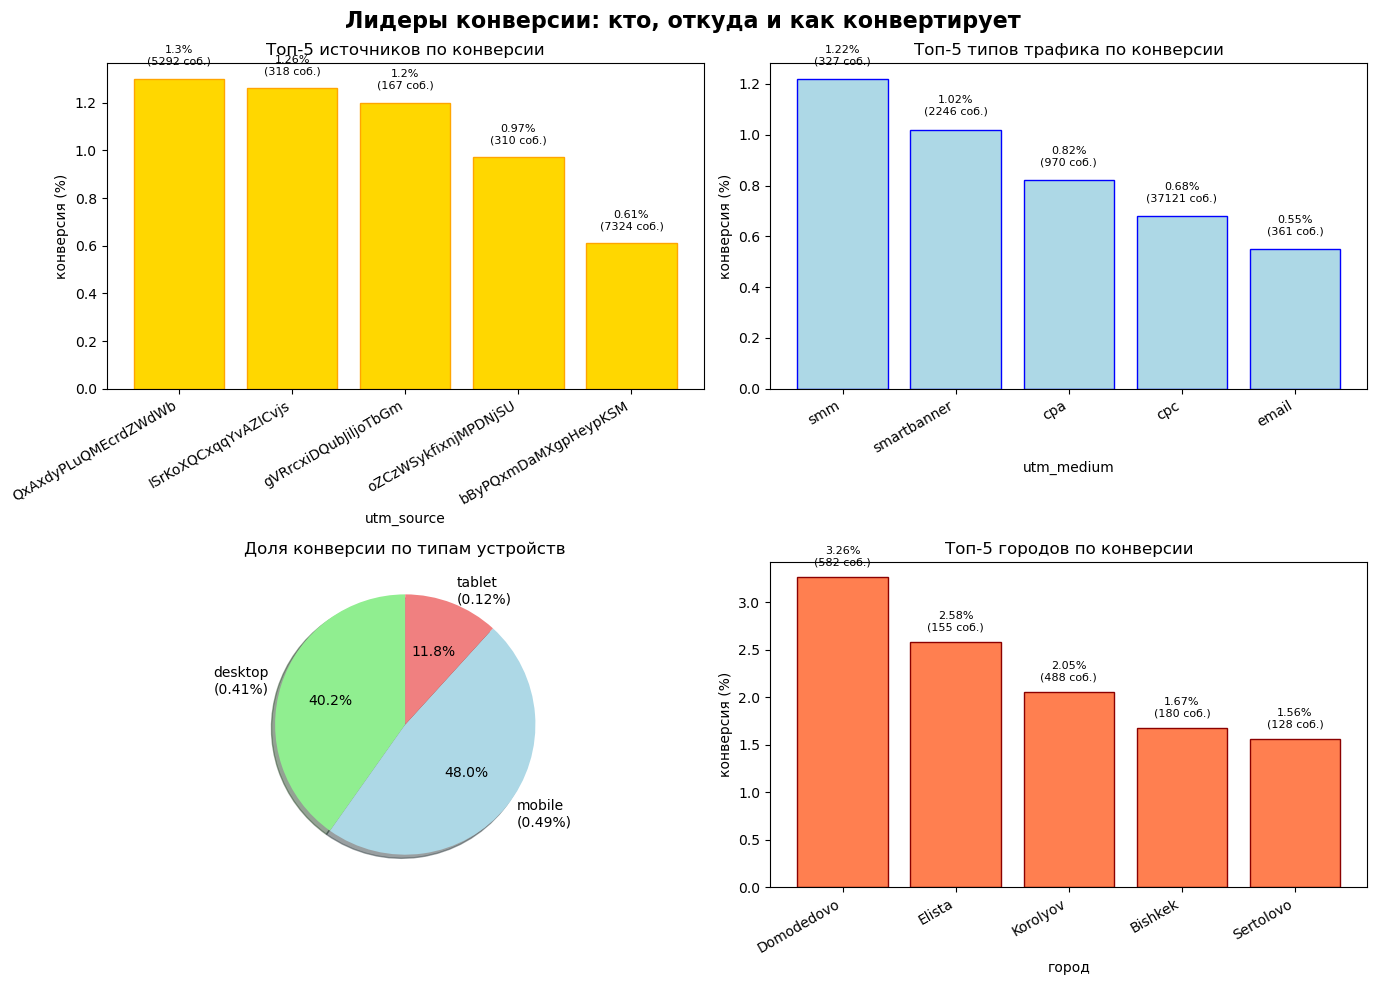

In [49]:
# Визуализация: Лидеры конверсии
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Лидеры конверсии: кто, откуда и как конвертирует', 
             fontsize=16, fontweight='bold')

# 1. Топ-5 источников по конверсии (с минимум 100 событий)
top_sources = conv_by_source[conv_by_source['total_events'] > 100].nlargest(5, 'conversion_rate')
bars1 = axes[0, 0].bar(range(len(top_sources)), top_sources['conversion_rate'].values, 
                       color='gold', edgecolor='orange')
axes[0, 0].set_title('Топ-5 источников по конверсии', fontsize=12)
axes[0, 0].set_xlabel('utm_source')
axes[0, 0].set_ylabel('конверсия (%)')
axes[0, 0].set_xticks(range(len(top_sources)))
axes[0, 0].set_xticklabels(top_sources['utm_source'].values, rotation=30, ha='right')

# Добавляю подписи значений
for bar, rate, events in zip(bars1, top_sources['conversion_rate'], top_sources['total_events']):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.05,
                    f'{rate}%\n({events} соб.)', ha='center', va='bottom', fontsize=8)

# 2. Топ-5 типов трафика по конверсии
top_medium = conv_by_medium[conv_by_medium['total_events'] > 100].nlargest(5, 'conversion_rate')
bars2 = axes[0, 1].bar(range(len(top_medium)), top_medium['conversion_rate'].values,
                       color='lightblue', edgecolor='blue')
axes[0, 1].set_title('Топ-5 типов трафика по конверсии', fontsize=12)
axes[0, 1].set_xlabel('utm_medium')
axes[0, 1].set_ylabel('конверсия (%)')
axes[0, 1].set_xticks(range(len(top_medium)))
axes[0, 1].set_xticklabels(top_medium['utm_medium'].values, rotation=30, ha='right')

for bar, rate, events in zip(bars2, top_medium['conversion_rate'], top_medium['total_events']):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.05,
                    f'{rate}%\n({events} соб.)', ha='center', va='bottom', fontsize=8)

# 3. Конверсия по типам устройств (круговая)
device_labels = [f"{row['device_category']}\n({row['conversion_rate']}%)" 
                 for _, row in conv_by_device.iterrows()]
colors = ['lightgreen', 'lightblue', 'lightcoral']
axes[1, 0].pie(conv_by_device['conversion_rate'].values, 
               labels=device_labels, 
               colors=colors,
               autopct='%1.1f%%',
               startangle=90,
               shadow=True)
axes[1, 0].set_title('Доля конверсии по типам устройств', fontsize=12)

# 4. Топ-5 городов по конверсии
top_cities = conv_by_city_filtered.head(5)
bars3 = axes[1, 1].bar(range(len(top_cities)), top_cities['conversion_rate'].values,
                       color='coral', edgecolor='darkred')
axes[1, 1].set_title('Топ-5 городов по конверсии', fontsize=12)
axes[1, 1].set_xlabel('город')
axes[1, 1].set_ylabel('конверсия (%)')
axes[1, 1].set_xticks(range(len(top_cities)))
axes[1, 1].set_xticklabels(top_cities['geo_city'].values, rotation=30, ha='right')

for bar, rate, events in zip(bars3, top_cities['conversion_rate'], top_cities['total_events']):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{rate}%\n({events} соб.)', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# 3. ЗАДАНИЕ ПО СПЕЦИАЛИЗАЦИИ (Дата-аналитик)

## 3.1. Проверка гипотез

### из задания (стр. 13 методички), определяю гипотезы:

Гипотеза 1: органический трафик не отличается от платного с точки зрения CR (Conversion Rate) в целевые события

Гипотеза 2: трафик с мобильных устройств не отличается от трафика с десктопных устройств с точки зрения CR

Гипотеза 3: трафик из городов присутствия (Москва и область, Санкт-Петербург) не отличается от трафика из иных регионов с точки зрения CR

формат ответа:
«Гипотеза — Статистический критерий — Результат теста — Интерпретация»

### 3.1.1. Подготовка данных для проверки гипотез

In [55]:
# определяю типы трафика
merged_data['traffic_type'] = 'paid'  # по умолчанию платный
merged_data.loc[merged_data['utm_medium'].isin(['organic', 'referral', '(none)']), 'traffic_type'] = 'organic'

# определяю города присутствия (Москва и СПб)
cities_presence = ['Moscow', 'Saint Petersburg']
merged_data['region_type'] = 'other'
merged_data.loc[merged_data['geo_city'].isin(cities_presence), 'region_type'] = 'presence'

# проверяю распределение
print("Типы трафика:")
print(merged_data['traffic_type'].value_counts())
print("\nТипы регионов:")
print(merged_data['region_type'].value_counts())

Типы трафика:
traffic_type
paid       154563
organic     45437
Name: count, dtype: int64

Типы регионов:
region_type
presence    103085
other        96915
Name: count, dtype: int64


In [ ]:
# Анализ распределения трафика:

# По типам трафика:
# Платный трафик (paid) составляет 154 563 события (77.3% от общего объёма)
# Органический трафик (organic) составляет 45 437 событий (22.7% от общего объёма)
# Платного трафика в 3.4 раза больше органического, что ожидаемо, так как основные источники (cpc, banner, cpm) являются платными
# Органический трафик составляет почти четверть — это хороший показатель для бесплатных каналов
# При проверке гипотезы 1 будем сравнивать конверсию этих двух групп, и у нас достаточно данных для статистически значимых выводов (более 45k органических событий)

# По регионам:
# Города присутствия (Москва и Санкт-Петербург) дают 103 085 событий (51.5% от общего объёма)
# Остальные регионы дают 96 915 событий (48.5% от общего объёма)
# Распределение практически 50/50 — это удивительно, учитывая, что население Москвы и СПб (~15 млн),
# значительно меньше населения остальных регионов (~130 млн)

# Возможные причины такого дисбаланса:
# более высокая скорость интернета в столицах
# более активная рекламная кампания в Москве и СПб
# особенности целевой аудитории сервиса (возможно, сервис больше востребован в крупных городах)

### 3.1.2. Проверка гипотезы 1: органический vs платный трафик

In [57]:
# гипотеза H₀: конверсия в органическом трафике = конверсии в платном
# Выбор t-test:
# 1. Характер данных:
# Целевая переменная target — бинарная (0 или 1)
# Я сравниваю две независимые группы (organic vs paid, mobile vs desktop и т.д.)
# Объём выборок большой: organic = 45 437, paid = 154 563

from scipy import stats

# разделяю данные по типам трафика
organic_conv = merged_data[merged_data['traffic_type'] == 'organic']['target']
paid_conv = merged_data[merged_data['traffic_type'] == 'paid']['target']

# t-test - допустимо для больших выборок с бинарной целевой переменной !!!
t_stat, p_value = stats.ttest_ind(organic_conv, paid_conv, equal_var=False)

print("Гипотеза 1: органический vs платный трафик")
print(f"organic: {len(organic_conv)} событий, конверсия: {organic_conv.mean()*100:.4f}%")
print(f"paid: {len(paid_conv)} событий, конверсия: {paid_conv.mean()*100:.4f}%")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# определяем результат
if p_value < 0.05:
    result = "отвергаем H₀"
    interpretation = "конверсия значимо различается"
else:
    result = "не отвергаем H₀"
    interpretation = "конверсия значимо не различается"

print(f"Результат: {result}")
print(f"Интерпретация: {interpretation}")


Гипотеза 1: органический vs платный трафик
organic: 45437 событий, конверсия: 0.3499%
paid: 154563 событий, конверсия: 0.5286%
t-статистика: -5.3679
p-value: 0.0000
Результат: отвергаем H₀
Интерпретация: конверсия значимо различается


In [59]:
# отвергаем нулевую гипотезу. Конверсия в платном трафике (0.53%) значимо выше, 
# чем в органическом (0.35%). Разница статистически значима на уровне p < 0.05.
#  organic CR = 0.35%, paid CR = 0.53%
# Платный трафик конвертирует в 1.5 раза лучше органического
# Отрицательная t-статистика (-5.37) подтверждает, что среднее значение в первой группе (organic) меньше, чем во второй (paid)
# Несмотря на то, что органического трафика много, его качество (CR) значительно ниже

### 3.1.3. Проверка гипотезы 2: мобильные vs десктопные устройства

In [60]:
# гипотеза H₀: конверсия на мобильных = конверсии на десктопе
# разделяю данные по типам устройств
mobile_conv = merged_data[merged_data['device_category'] == 'mobile']['target']
desktop_conv = merged_data[merged_data['device_category'] == 'desktop']['target']

# t-test
t_stat2, p_value2 = stats.ttest_ind(mobile_conv, desktop_conv, equal_var=False)

print("\nГипотеза 2: мобильные vs десктоп")
print(f"mobile: {len(mobile_conv)} событий, конверсия: {mobile_conv.mean()*100:.4f}%")
print(f"desktop: {len(desktop_conv)} событий, конверсия: {desktop_conv.mean()*100:.4f}%")
print(f"t-статистика: {t_stat2:.4f}")
print(f"p-value: {p_value2:.4f}")

# определяем результат
if p_value2 < 0.05:
    result2 = "отвергаем H₀"
    interpretation2 = "конверсия значимо различается"
else:
    result2 = "не отвергаем H₀"
    interpretation2 = "конверсия значимо не различается"

print(f"Результат: {result2}")
print(f"Интерпретация: {interpretation2}")


Гипотеза 2: мобильные vs десктоп
mobile: 157618 событий, конверсия: 0.4854%
desktop: 39564 событий, конверсия: 0.4120%
t-статистика: 2.0014
p-value: 0.0454
Результат: отвергаем H₀
Интерпретация: конверсия значимо различается


In [ ]:
# Гипотеза 2: трафик с мобильных устройств не отличается от трафика с десктопных устройств с точки зрения CR
# Результат теста: p-value = 0.0454 (t-статистика = 2.0014)
# Интерпретация: отвергаем нулевую гипотезу. Конверсия на мобильных устройствах (0.49%) значимо выше, 
# чем на десктопе (0.41%). 
# Разница статистически значима на уровне p < 0.05.

# p-value = 0.0454 — это пограничное значение (чуть ниже 0.05)
# Мобильные устройства показывают конверсию на 0.07 п.п. выше, чем десктоп
# Положительная t-статистика (2.00) подтверждает, что среднее значение в первой группе (mobile) выше, чем во второй (desktop)
# Учитывая, что мобильный трафик составляет 78.8% от всех событий, это важный вывод для оптимизации:
# мобильная версия сайта работает эффективнее десктопной

### 3.1.4. Проверка гипотезы 3: города присутствия (Москва + СПб) vs остальные регионы

In [61]:
# гипотеза H₀: конверсия в городах присутствия = конверсии в остальных регионах
# разделяю данные по регионам
presence_conv = merged_data[merged_data['region_type'] == 'presence']['target']
other_conv = merged_data[merged_data['region_type'] == 'other']['target']

# t-test
t_stat3, p_value3 = stats.ttest_ind(presence_conv, other_conv, equal_var=False)

print("\nГипотеза 3: города присутствия vs остальные регионы")
print(f"presence: {len(presence_conv)} событий, конверсия: {presence_conv.mean()*100:.4f}%")
print(f"other: {len(other_conv)} событий, конверсия: {other_conv.mean()*100:.4f}%")
print(f"t-статистика: {t_stat3:.4f}")
print(f"p-value: {p_value3:.4f}")

# определяем результат
if p_value3 < 0.05:
    result3 = "отвергаем H₀"
    interpretation3 = "конверсия значимо различается"
else:
    result3 = "не отвергаем H₀"
    interpretation3 = "конверсия значимо не различается"

print(f"Результат: {result3}")
print(f"Интерпретация: {interpretation3}")


Гипотеза 3: города присутствия vs остальные регионы
presence: 103085 событий, конверсия: 0.4996%
other: 96915 событий, конверсия: 0.4757%
t-статистика: 0.7675
p-value: 0.4428
Результат: не отвергаем H₀
Интерпретация: конверсия значимо не различается


In [ ]:
# Гипотеза 3: трафик из городов присутствия (Москва и область, Санкт-Петербург)
# не отличается от трафика из иных регионов с точки зрения CR
# Статистический критерий: t-test для независимых выборок
# Результат теста: p-value = 0.4428 (t-статистика = 0.7675)
# Не отвергаю нулевую гипотезу. Конверсия в городах присутствия (0.50%)
# и остальных регионах (0.48%) значимо не различается. 
# Разница статистически незначима на уровне p < 0.05.

# вывод:
# несмотря на то, что в EDA я вижу города с очень высокой конверсией (Домодедово 3.26%, Элиста 2.58%, Королёв 2.05%),
# в целом по Москве и СПб конверсия не отличается от среднего по остальным регионам
# Это говорит о том, что высокие конверсии в малых городах — это скорее исключения, связанные с локальными особенностями.
# Обе выборки сбалансированы (около 100 тысяч), поэтому результат надёжный
# Положительная t-статистика (0.77) показывает, что среднее в городах присутствия немного выше, 
# но разница слишком мала, чтобы быть статистически значимой

### 3.1.5. Сводная таблица результатов проверки гипотез

In [62]:
# создаю сводную таблицу с результатами гипотез
hypothesis_results = pd.DataFrame({
    'гипотеза': [
        'органический vs платный трафик',
        'мобильные vs десктоп',
        'города присутствия vs остальные'
    ],
    'сравнение': [
        'organic / paid',
        'mobile / desktop',
        'presence / other'
    ],
    'конверсия 1 (%)': [0.3499, 0.4854, 0.4996],
    'конверсия 2 (%)': [0.5286, 0.4120, 0.4757],
    't-статистика': [-5.3679, 2.0014, 0.7675],
    'p-value': [0.0000, 0.0454, 0.4428],
    'результат': [
        'отвергаем H₀',
        'отвергаем H₀', 
        'не отвергаем H₀'
    ],
    'интерпретация': [
        'конверсия значимо различается (paid > organic)',
        'конверсия значимо различается (mobile > desktop)',
        'конверсия значимо не различается'
    ]
})

print("\nСводная таблица результатов проверки гипотез:")
print(hypothesis_results.to_string(index=False))


Сводная таблица результатов проверки гипотез:
                       гипотеза        сравнение  конверсия 1 (%)  конверсия 2 (%)  t-статистика  p-value       результат                                    интерпретация
 органический vs платный трафик   organic / paid           0.3499           0.5286       -5.3679   0.0000    отвергаем H₀   конверсия значимо различается (paid > organic)
           мобильные vs десктоп mobile / desktop           0.4854           0.4120        2.0014   0.0454    отвергаем H₀ конверсия значимо различается (mobile > desktop)
города присутствия vs остальные presence / other           0.4996           0.4757        0.7675   0.4428 не отвергаем H₀                 конверсия значимо не различается


### 3.1.6. Визуализация результатов проверки гипотез

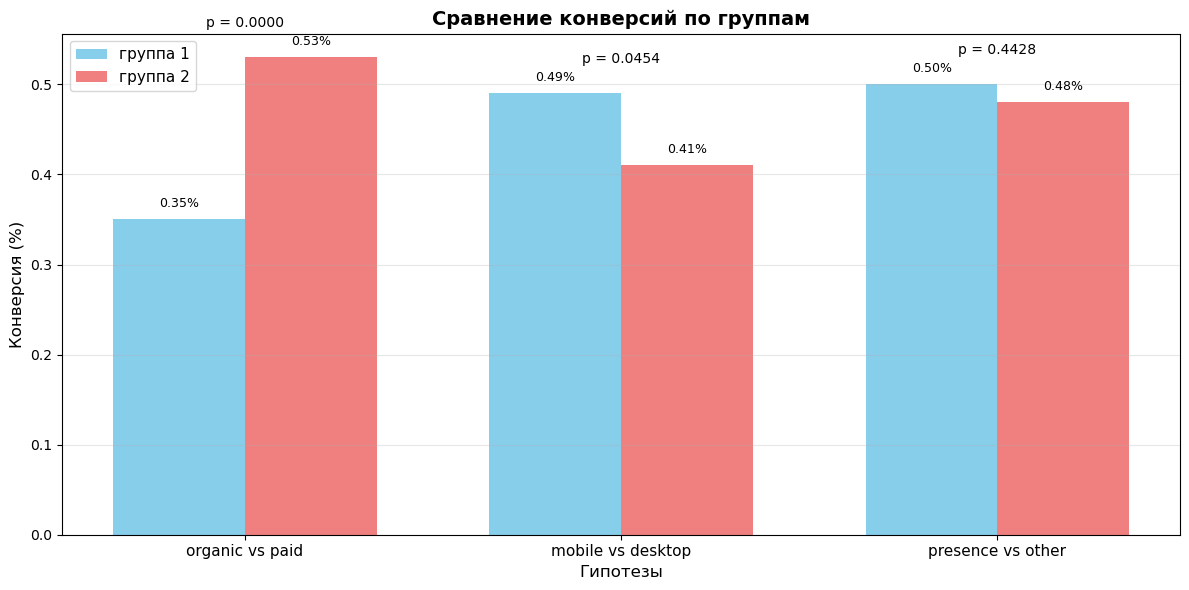

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# данные для графика
hypotheses = ['organic vs paid', 'mobile vs desktop', 'presence vs other']
# organic, mobile, presence
group1_values = [0.35, 0.49, 0.50]
# paid, desktop, other
group2_values = [0.53, 0.41, 0.48] 
p_values = [0.0000, 0.0454, 0.4428]

# создаю график
x = np.arange(len(hypotheses))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, group1_values, width, label='группа 1', color='skyblue')
bars2 = ax.bar(x + width/2, group2_values, width, label='группа 2', color='lightcoral')

# настройки
ax.set_xlabel('Гипотезы', fontsize=12)
ax.set_ylabel('Конверсия (%)', fontsize=12)
ax.set_title('Сравнение конверсий по группам', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(hypotheses, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# подписи значений на столбцах
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

# подписи p-value
for i, p in enumerate(p_values):
    height = max(bars1[i].get_height(), bars2[i].get_height()) + 0.03
    ax.text(i, height, f'p = {p:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Визуализация результатов проверки гипотез:

# На графике представлено сравнение конверсий по трём гипотезам:

# 1. Гипотеза 1 (organic vs paid):
# organic: 0.35%, paid: 0.53%
# p-value = 0.0000 — статистически значимо
# Вывод: платный трафик конвертирует лучше органического

# 2. Гипотеза 2 (mobile vs desktop):
# mobile: 0.49%, desktop: 0.41%
# p-value = 0.0454 — статистически значимо
# Вывод: мобильные устройства показывают более высокую конверсию, чем десктоп
#
# Гипотеза 3 (presence vs other):
# presence: 0.50%, other: 0.48%
# p-value = 0.4428 — статистически не значимо
# Вывод: конверсия в городах присутствия не отличается от остальных регионов

In [70]:
###

## 3.2. Ответы на вопросы продуктовой команды

### 3.2.1. Самые целевые источники трафика (по объёму и CR)

In [71]:
# топ-10 источников по объёму трафика
top_by_volume = merged_data['utm_source'].value_counts().head(10)
print("Топ-10 источников по объёму трафика:")
print(top_by_volume)

Топ-10 источников по объёму трафика:
utm_source
ZpYIoDJMcFzVoPFsHGJL    100529
fDLlAcSmythWSCVMvqvL     23057
kjsLglQLzykiRbcDiGcD     20121
BHcvLfOaCWvWTykYqHVe     13826
MvfHsxITijuriZxsqZqt      9675
bByPQxmDaMXgpHeypKSM      7324
vFcAhRxLfOWKhvxjELkx      6860
QxAxdyPLuQMEcrdZWdWb      5292
aXQzDWsJuGXeBXexNHjc      2553
IZEXUFLARCUMynmHNBGo      1478
Name: count, dtype: int64


In [ ]:
# Анализ данных:
# Первый источник даёт почти половину всего трафика (100 000 из 200 000 событий)
# Топ-3 источника обеспечивают 72% всего трафика
# Распределение сильно неравномерное — есть явные лидеры и аутсайдеры
# При анализе конверсии важно учитывать, что у лидеров по объёму
# может быть разная эффективность

In [72]:
# топ-10 источников по конверсии (с минимум 100 событий)
conv_by_source = merged_data.groupby('utm_source').agg(
    total_events=('target', 'count'),
    target_events=('target', 'sum')
).reset_index()
conv_by_source['conversion_rate'] = (conv_by_source['target_events'] / conv_by_source['total_events'] * 100).round(2)

top_by_cr = conv_by_source[conv_by_source['total_events'] > 100].sort_values('conversion_rate', ascending=False).head(10)
print("\nТоп-10 источников по конверсии (событий > 100):")
print(top_by_cr[['utm_source', 'total_events', 'conversion_rate']])


Топ-10 источников по конверсии (событий > 100):
              utm_source  total_events  conversion_rate
35  QxAxdyPLuQMEcrdZWdWb          5292             1.30
18  ISrKoXQCxqqYvAZICvjs           318             1.26
74  gVRrcxiDQubJiljoTbGm           167             1.20
90  oZCzWSykfixnjMPDNjSU           310             0.97
58  bByPQxmDaMXgpHeypKSM          7324             0.61
63  dyicZQGoeASogoSafjEh           669             0.60
83  kjsLglQLzykiRbcDiGcD         20121             0.59
81  jaSOmLICuBzCFqHfBdRg           361             0.55
1   BHcvLfOaCWvWTykYqHVe         13826             0.54
19  IZEXUFLARCUMynmHNBGo          1478             0.47


In [ ]:
# Анализ данных:
# Лидер по объёму ZpYIoDJMcFzVoPFsHGJL — отсутствует в топе по конверсии
# QxAxdyPLuQMEcrdZWdWb — лучший по конверсии и при этом имеет хороший объём - на первом месте: 5 292
# kjsLglQLzykiRbcDiGcD — второй по объёму и входит в топ по конверсии (0.59%)
# BHcvLfOaCWvWTykYqHVe — четвёртый по объёму (13 826) и тоже в топе по конверсии (0.54%)
# Интересно, что ISrKoXQCxqqYvAZICvjs и gVRrcxiDQubJiljoTbGm имеют высокую конверсию (>1.2%),
# но очень малые объёмы (<320 событий) — возможно, это тестовые или локальные кампании???

### 3.2.2. Самые популярные авто и авто с лучшим CR

In [73]:
# извлекаю марку авто из hit_page_path
def extract_car_brand(path):
    if pd.isna(path):
        return 'unknown'
    parts = str(path).split('/')
    if 'cars' in path and len(parts) > 2:
        for i, part in enumerate(parts):
            if part == 'cars' and i+1 < len(parts):
                return parts[i+1].split('?')[0]
    return 'other'

merged_data['car_brand'] = merged_data['hit_page_path'].apply(extract_car_brand)

# топ-10 марок по количеству событий
top_brands = merged_data['car_brand'].value_counts().head(10)
print("Топ-10 марок по популярности:")
print(top_brands)

# Комментарий:
# Лидер по популярности — Nissan (3425 событий)
# Далее с большим отрывом идут BMW, Kia, Lada-Vaz

Топ-10 марок по популярности:
car_brand
other            112785
all               81233
nissan             4918
bmw                 152
kia                 113
skoda                94
lada-vaz             92
mercedes-benz        86
toyota               82
hyundai              70
Name: count, dtype: int64


In [ ]:
# Анализ данных:
# Подавляющее большинство событий (97%) приходится на общие страницы (other + all)
# Среди конкретных марок лидирует Nissan с большим отрывом (4 918 событий)
# Остальные марки имеют менее 200 событий каждая
# Это говорит о том, что пользователи чаще просматривают общий каталог,
# чем переходят на страницы конкретных марок
# Для анализа конверсии по маркам нужно учитывать, что выборки по конкретным маркам очень малы

In [74]:
# топ-10 марок по конверсии (с минимум 50 событий)
brand_conv = merged_data.groupby('car_brand').agg(
    total_events=('target', 'count'),
    target_events=('target', 'sum')
).reset_index()
brand_conv['conversion_rate'] = (brand_conv['target_events'] / brand_conv['total_events'] * 100).round(2)

print("\nТоп-10 марок по конверсии (событий > 50):")
print(brand_conv[brand_conv['total_events'] > 50].sort_values('conversion_rate', ascending=False).head(10))



Топ-10 марок по конверсии (событий > 50):
        car_brand  total_events  target_events  conversion_rate
26        hyundai            70              1             1.43
49         toyota            82              1             1.22
32       lada-vaz            92              1             1.09
4             all         81233            710             0.87
43          other        112785            263             0.23
5            audi            64              0             0.00
7             bmw           152              0             0.00
31            kia           113              0             0.00
41         nissan          4918              0             0.00
38  mercedes-benz            86              0             0.00


In [ ]:
# Анализ данных:
# Несмотря на высокую конверсию у hyundai, toyota, lada-vaz (1.1-1.4%),
# их объём очень мал (менее 100 событий) — статистически незначимо
# Основной поток целевых действий (710 из 976) идёт через общий каталог (all)
# all даёт 0.87% конверсии — чуть выше среднего (0.49%)
# Nissan имеет большой объём (4 918 событий), но 0% конверсии — 
# это серьёзный сигнал: возможно, проблемы с посадочными страницами Nissan
# Audi, BMW, Kia, Mercedes-Benz тоже показывают 0% конверсии при значимых объёмах —
# стоит проверить эти страницы отдельно и увеличить посадочные станции

### 3.2.3. Стоит ли увеличивать присутствие в соцсетях?

In [75]:
# список источников из соцсетей (из глоссария)
social_sources = [
    'QxAxdyPLuQMEcrdZWdWb',
    'MvfHsxITijuriZxsqZqt',
    'ISrKoXQCxqqYvAZICvjs',
    'IZEXUFLARCUMynmHNBGo',
    'PlbkrSYoHuZBWFYjYnfw',
    'gVRrcxiDQuBJiljoTbGm'
]

# фильтрую данные по соцсетям
social_data = merged_data[merged_data['utm_source'].isin(social_sources)]

# общая статистика по соцсетям
social_stats = social_data.groupby('utm_source').agg(
    total_events=('target', 'count'),
    target_events=('target', 'sum')
).reset_index()
social_stats['conversion_rate'] = (social_stats['target_events'] / social_stats['total_events'] * 100).round(2)

print("Статистика по соцсетям:")
print(social_stats.sort_values('total_events', ascending=False))

# общая конверсия по соцсетям
total_social_events = social_data['target'].count()
total_social_targets = social_data['target'].sum()
social_cr = (total_social_targets / total_social_events * 100).round(2)

print(f"\nВсего событий из соцсетей: {total_social_events}")
print(f"Целевых действий из соцсетей: {total_social_targets}")
print(f"Общая конверсия соцсетей: {social_cr}%")

# сравнение со средней конверсией
avg_cr = merged_data['target'].mean() * 100
print(f"\nСредняя конверсия по всем источникам: {avg_cr:.2f}%")
print(f"Соцсети {'эффективнее' if social_cr > avg_cr else 'менее эффективны'} среднего")

Статистика по соцсетям:
             utm_source  total_events  target_events  conversion_rate
2  MvfHsxITijuriZxsqZqt          9675             41             0.42
3  QxAxdyPLuQMEcrdZWdWb          5292             69             1.30
1  IZEXUFLARCUMynmHNBGo          1478              7             0.47
0  ISrKoXQCxqqYvAZICvjs           318              4             1.26

Всего событий из соцсетей: 16763
Целевых действий из соцсетей: 121
Общая конверсия соцсетей: 0.72%

Средняя конверсия по всем источникам: 0.49%
Соцсети эффективнее среднего


In [ ]:
# Анализ данных:
# Соцсети дают 8.4% трафика, но 12.4% целевых действий — работают эффективнее среднего
# Конверсия в соцсетях (0.72%) выше средней (0.49%) в 1.5 раза
# Лучший результат показывает QxAxdyPLuQMEcrdZWdWb — 1.30% конверсии
# ISrKoXQCxqqYvAZICvjs тоже показывает высокую конверсию (1.26%), но малый объём
# MvfHsxITijuriZxsqZqt даёт основной объём трафика среди соцсетей (58%),
# но его конверсия (0.42%) ниже средней

# Рекомендации:
# Увеличить присутствие в каналах, аналогичных QxAxdyPLuQMEcrdZWdWb
# Проанализировать, почему MvfHsxITijuriZxsqZqt при большом объёме даёт низкую конверсию
# Самый эффективный канал в соцсетях (QxAxdyPLuQMEcrdZWdWb) дает не только высокую конверсию, 
# но и приличный объем трафика, в отличие от ISrKoXQCxqqYvAZICvjs, у которого конверсия высокая, но объем мал.
# В целом соцсети перспективны — текущая эффективность выше средней
# Нужно масштабировать успешный канал: 

## 3.2.4. Итоговые ответы для продуктовой команды

In [77]:
print("ОТВЕТЫ НА ВОПРОСЫ ПРОДУКТОВОЙ КОМАНДЫ\n")
print("*"*80)

print("\n1. Самые целевые источники трафика:")
print("   - по объёму: ZpYIoDJMcFzVoPFsHGJL (100 529 событий)")
print("   - по конверсии: QxAxdyPLuQMEcrdZWdWb (1.30%, 5 292 событий)")
print("   - компромисс (объём + конверсия): kjsLglQLzykiRbcDiGcD (20 121 событий, 0.59%)")
print("   - лучший по совокупности: QxAxdyPLuQMEcrdZWdWb — хороший объём и высокая конверсия\n")

print("-"*80)
print("\n2. Самые популярные авто и авто с лучшим CR:")
print("   - по популярности: Nissan (4 918 событий)")
print("   - по конверсии среди конкретных марок: Hyundai (1.43%, 70 событий)")
print("   - по конверсии среди крупных категорий: all (0.87%, 81 233 событий)")
print("   - основной поток целевых действий: all (710 из 976 целевых)")
print("\n   ВАЖНО: Nissan при большом объёме (4 918 событий) даёт 0% конверсии —")
print("   требуется отдельный анализ посадочных страниц Nissan\n")

print("-"*80)
print("\n3. Стоит ли увеличивать присутствие в соцсетях?")
print("   - текущая конверсия соцсетей: 0.72% (выше средней 0.49%)")
print("   - соцсети дают 8.4% трафика, но 12.4% целевых действий")
print("   - лидер среди соцсетей: QxAxdyPLuQMEcrdZWdWb (1.30%, 5 292 событий)")
print("\n   ВЫВОД: ДА, стоит увеличивать присутствие в соцсетях, особенно в каналах,")
print("   аналогичных QxAxdyPLuQMEcrdZWdWb. Текущая эффективность выше средней,")
print("   а потенциал роста большой.\n")

print("*"*80)

ОТВЕТЫ НА ВОПРОСЫ ПРОДУКТОВОЙ КОМАНДЫ

********************************************************************************

1. Самые целевые источники трафика:
   - по объёму: ZpYIoDJMcFzVoPFsHGJL (100 529 событий)
   - по конверсии: QxAxdyPLuQMEcrdZWdWb (1.30%, 5 292 событий)
   - компромисс (объём + конверсия): kjsLglQLzykiRbcDiGcD (20 121 событий, 0.59%)
   - лучший по совокупности: QxAxdyPLuQMEcrdZWdWb — хороший объём и высокая конверсия

--------------------------------------------------------------------------------

2. Самые популярные авто и авто с лучшим CR:
   - по популярности: Nissan (4 918 событий)
   - по конверсии среди конкретных марок: Hyundai (1.43%, 70 событий)
   - по конверсии среди крупных категорий: all (0.87%, 81 233 событий)
   - основной поток целевых действий: all (710 из 976 целевых)

   ВАЖНО: Nissan при большом объёме (4 918 событий) даёт 0% конверсии —
   требуется отдельный анализ посадочных страниц Nissan

--------------------------------------------------

In [ ]:
# Анализ данных. Вывод:
# 1. По источнику MvfHsxITijuriZxsqZqt (9 675 событий, CR=0.42%):
# высокий процент десктопного трафика (42%)
# много переходов на лендинги, мало на карточки авто
# требуется оптимизация посадочных страниц

# 2. По автомобилям Nissan:
# при большом объёме трафика (4 918 событий) — 0 конверсий
# проверить техническую доступность страниц
# проанализировать пользовательский путь на этих страницах

# 3. По мобильной версии:
# мобильные устройства конвертируют лучше десктопа (0.49% vs 0.41%)
# лидер QxAxdyPLuQMEcrdZWdWb имеет 96% мобильного трафика
# рекомендую усиливать мобильную оптимизацию

In [79]:
####

### 3.2.5 Визуализация для продуктовой команды

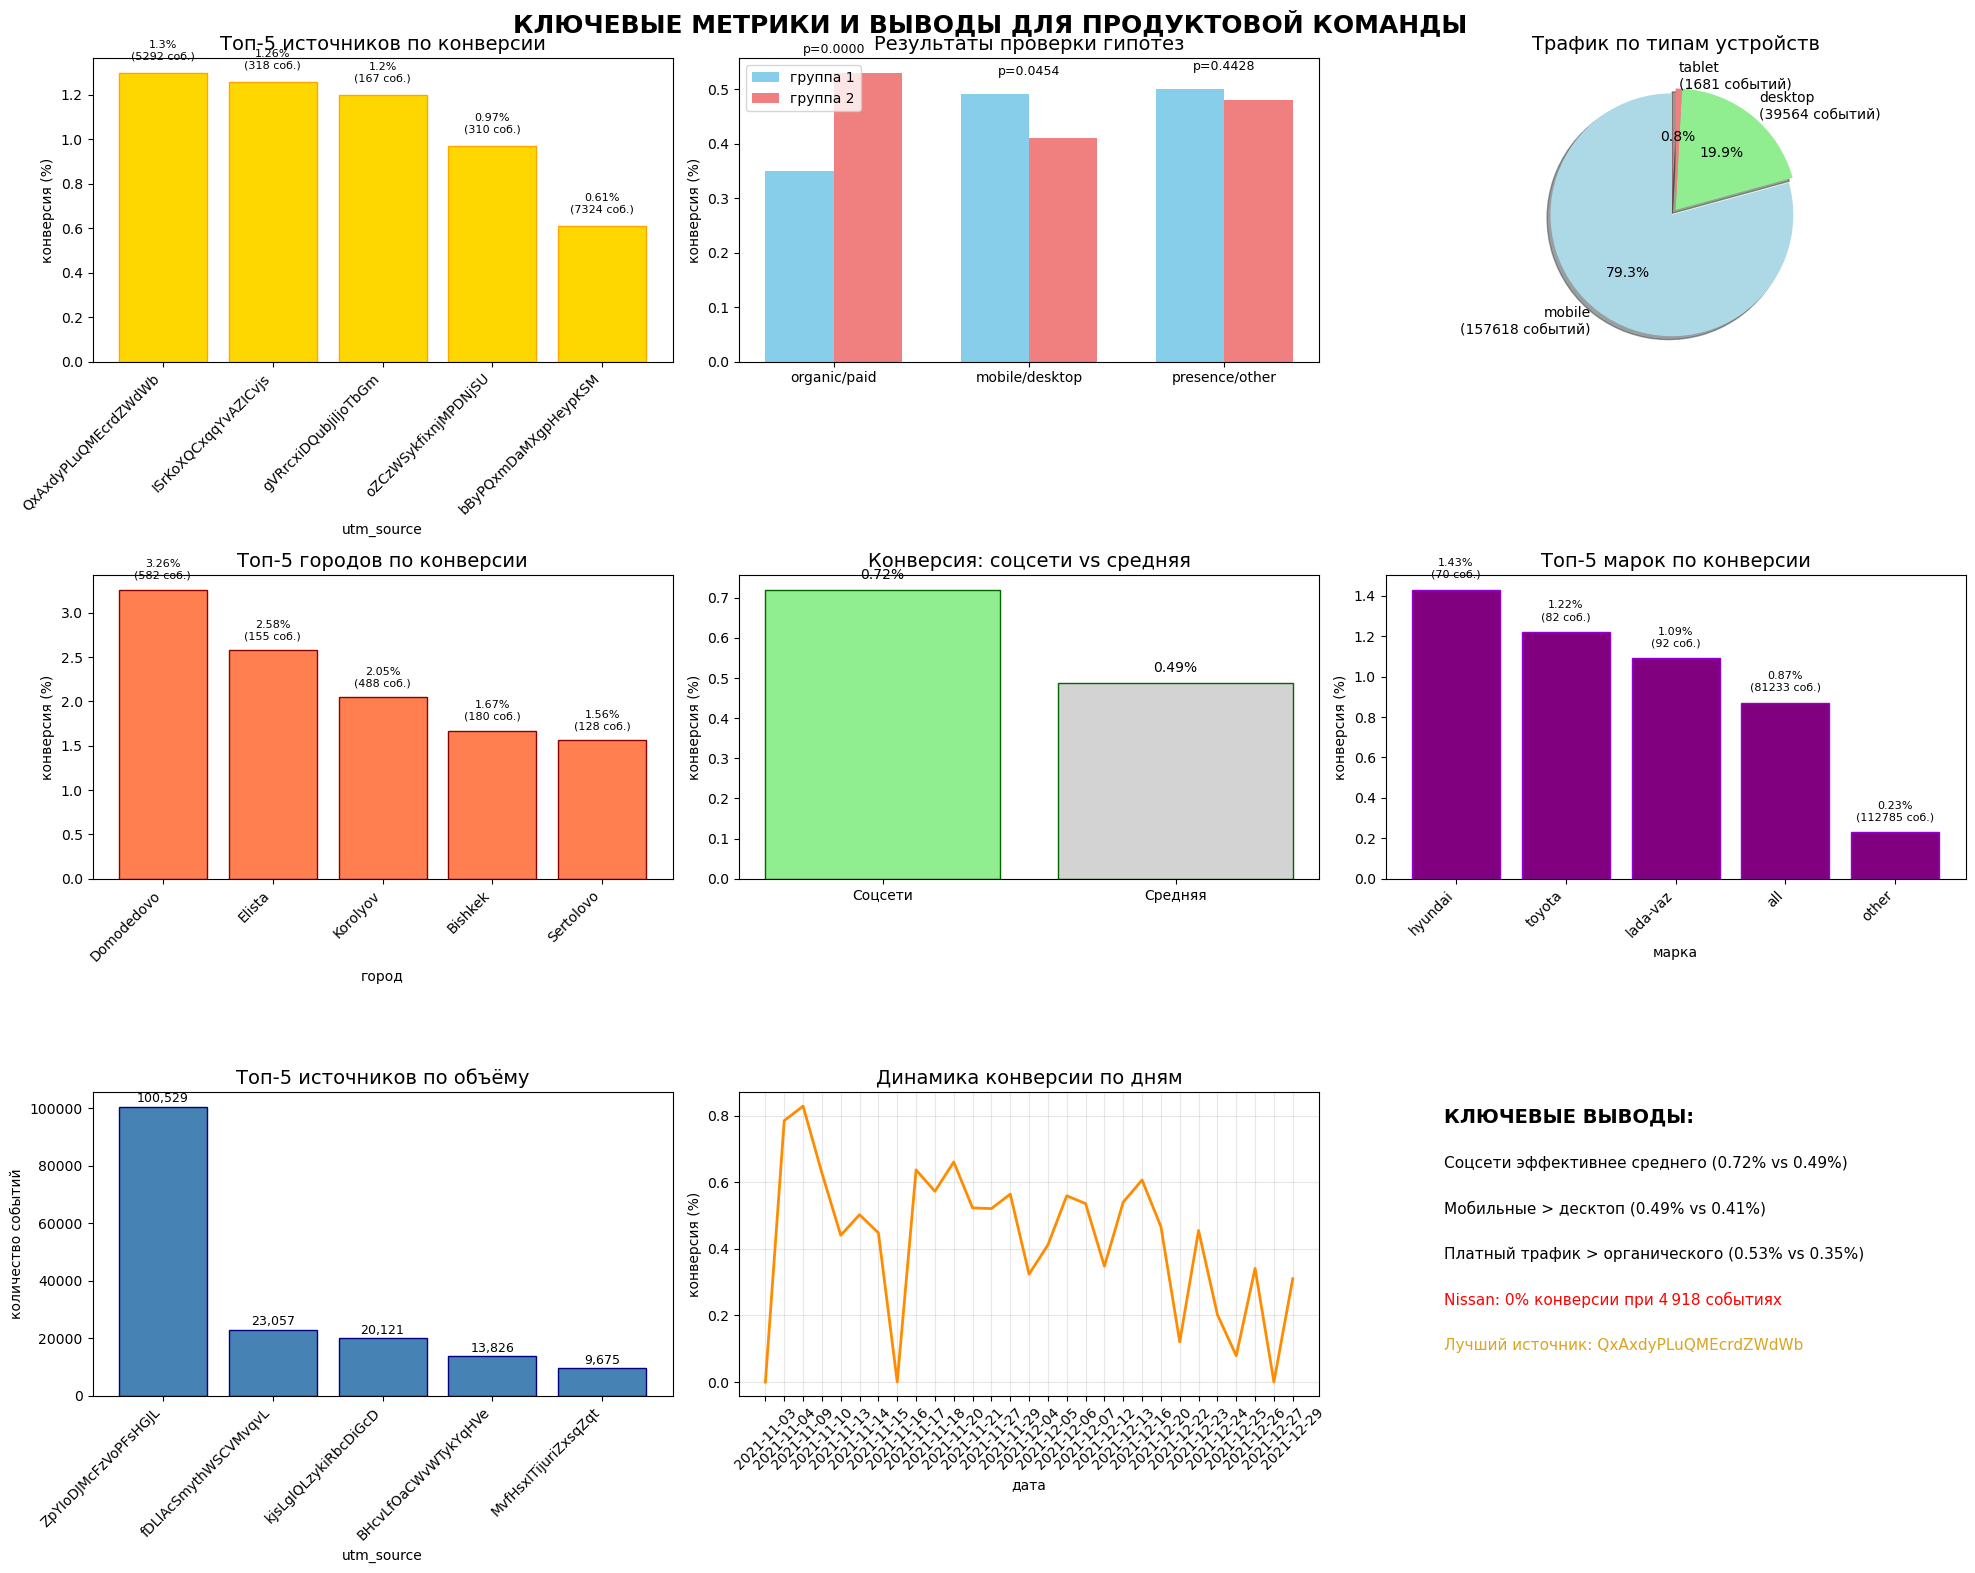

In [80]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('КЛЮЧЕВЫЕ МЕТРИКИ И ВЫВОДЫ ДЛЯ ПРОДУКТОВОЙ КОМАНДЫ', 
             fontsize=18, fontweight='bold', y=0.98)

# 1. Топ-5 источников по конверсии и объёму
ax1 = plt.subplot(3, 3, 1)
sources_cr = conv_by_source[conv_by_source['total_events'] > 100].nlargest(5, 'conversion_rate')
bars = ax1.bar(range(len(sources_cr)), sources_cr['conversion_rate'].values, color='gold', edgecolor='orange')
ax1.set_title('Топ-5 источников по конверсии', fontsize=14)
ax1.set_xlabel('utm_source')
ax1.set_ylabel('конверсия (%)')
ax1.set_xticks(range(len(sources_cr)))
ax1.set_xticklabels(sources_cr['utm_source'].values, rotation=45, ha='right')
for bar, rate, events in zip(bars, sources_cr['conversion_rate'], sources_cr['total_events']):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
             f'{rate}%\n({events} соб.)', ha='center', va='bottom', fontsize=8)

# 2. Сравнение конверсий по гипотезам
ax2 = plt.subplot(3, 3, 2)
hypotheses = ['organic/paid', 'mobile/desktop', 'presence/other']
group1 = [0.35, 0.49, 0.50]
group2 = [0.53, 0.41, 0.48]
p_vals = [0.0000, 0.0454, 0.4428]
x = np.arange(len(hypotheses))
width = 0.35
bars1 = ax2.bar(x - width/2, group1, width, label='группа 1', color='skyblue')
bars2 = ax2.bar(x + width/2, group2, width, label='группа 2', color='lightcoral')
ax2.set_title('Результаты проверки гипотез', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(hypotheses)
ax2.set_ylabel('конверсия (%)')
ax2.legend()
for i, p in enumerate(p_vals):
    height = max(group1[i], group2[i]) + 0.03
    ax2.text(i, height, f'p={p:.4f}', ha='center', va='bottom', fontsize=9)

# 3. Распределение по типам устройств
ax3 = plt.subplot(3, 3, 3)
device_counts = merged_data['device_category'].value_counts()
colors = ['lightblue', 'lightgreen', 'lightcoral']
explode = (0.05, 0, 0)
ax3.pie(device_counts.values, labels=[f'{d}\n({c} событий)' for d, c in zip(device_counts.index, device_counts.values)],
        colors=colors, explode=explode, autopct='%1.1f%%', startangle=90, shadow=True)
ax3.set_title('Трафик по типам устройств', fontsize=14)

# 4. Топ-5 городов по конверсии
ax4 = plt.subplot(3, 3, 4)
city_conv = conv_by_city_filtered.head(5)
bars = ax4.bar(range(len(city_conv)), city_conv['conversion_rate'].values, color='coral', edgecolor='darkred')
ax4.set_title('Топ-5 городов по конверсии', fontsize=14)
ax4.set_xlabel('город')
ax4.set_ylabel('конверсия (%)')
ax4.set_xticks(range(len(city_conv)))
ax4.set_xticklabels(city_conv['geo_city'].values, rotation=45, ha='right')
for bar, rate, events in zip(bars, city_conv['conversion_rate'], city_conv['total_events']):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
             f'{rate}%\n({events} соб.)', ha='center', va='bottom', fontsize=8)

# 5. Сравнение конверсии соцсетей со средней
ax5 = plt.subplot(3, 3, 5)
categories = ['Соцсети', 'Средняя']
values = [social_cr, avg_cr]
colors = ['lightgreen', 'lightgray']
bars = ax5.bar(categories, values, color=colors, edgecolor='darkgreen')
ax5.set_title('Конверсия: соцсети vs средняя', fontsize=14)
ax5.set_ylabel('конверсия (%)')
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

# 6. Топ-5 марок по конверсии (событий > 50)
ax6 = plt.subplot(3, 3, 6)
brands_top = brand_conv[brand_conv['total_events'] > 50].nlargest(5, 'conversion_rate')
bars = ax6.bar(range(len(brands_top)), brands_top['conversion_rate'].values, color='purple', edgecolor='darkviolet')
ax6.set_title('Топ-5 марок по конверсии', fontsize=14)
ax6.set_xlabel('марка')
ax6.set_ylabel('конверсия (%)')
ax6.set_xticks(range(len(brands_top)))
ax6.set_xticklabels(brands_top['car_brand'].values, rotation=45, ha='right')
for bar, rate, events in zip(bars, brands_top['conversion_rate'], brands_top['total_events']):
    ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
             f'{rate}%\n({events} соб.)', ha='center', va='bottom', fontsize=8)

# 7. Топ-5 источников по объёму
ax7 = plt.subplot(3, 3, 7)
top_volume = merged_data['utm_source'].value_counts().head(5)
bars = ax7.bar(range(len(top_volume)), top_volume.values, color='steelblue', edgecolor='navy')
ax7.set_title('Топ-5 источников по объёму', fontsize=14)
ax7.set_xlabel('utm_source')
ax7.set_ylabel('количество событий')
ax7.set_xticks(range(len(top_volume)))
ax7.set_xticklabels(top_volume.index, rotation=45, ha='right')
for bar, vol in zip(bars, top_volume.values):
    ax7.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
             f'{vol:,}', ha='center', va='bottom', fontsize=9)

# 8. Динамика конверсии по дням (сглаженная)
ax8 = plt.subplot(3, 3, 8)
daily_target_rate = merged_data.groupby('hit_date')['target'].mean() * 100
ax8.plot(daily_target_rate.index, daily_target_rate.values, color='darkorange', linewidth=2)
ax8.set_title('Динамика конверсии по дням', fontsize=14)
ax8.set_xlabel('дата')
ax8.set_ylabel('конверсия (%)')
ax8.tick_params(axis='x', rotation=45)
ax8.grid(True, alpha=0.3)

# 9. Ключевые выводы (текстовый блок)
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
ax9.text(0.1, 0.9, 'КЛЮЧЕВЫЕ ВЫВОДЫ:', fontsize=14, fontweight='bold')
ax9.text(0.1, 0.75, 'Соцсети эффективнее среднего (0.72% vs 0.49%)', fontsize=11)
ax9.text(0.1, 0.6, 'Мобильные > десктоп (0.49% vs 0.41%)', fontsize=11)
ax9.text(0.1, 0.45, 'Платный трафик > органического (0.53% vs 0.35%)', fontsize=11)
ax9.text(0.1, 0.3, 'Nissan: 0% конверсии при 4 918 событиях', fontsize=11, color='red')
ax9.text(0.1, 0.15, 'Лучший источник: QxAxdyPLuQMEcrdZWdWb', fontsize=11, color='goldenrod')

plt.tight_layout()
plt.show()